# 04 — Обнаружение неожиданных изменений расходов

## Цель исследования

В предыдущих этапах мы построили модели прогнозирования муниципальных расходов.
Теперь решаем другую задачу: **обнаруживаем нетипичные изменения, которые
выделяются на фоне поведения похожих муниципалитетов**.

В этом ноутбуке сравниваются два метода:

1. **Cross-sectional baseline** — ищет резкое изменение годовой динамики относительно всей панели.
2. **Size-aware forecast-surprise detector** — сравнивает фактические расходы с каузальным прогнозом и нормирует ошибку отдельно для пяти групп МО по размеру расходов.

Детектор не утверждает, что любое отклонение вызвано реальным экономическим событием:
он формирует **сигналы для дальнейшей проверки**.

## Как измеряем качество

Главная оценка выполняется на уровне **событий**.

- **Event Recall** — доля внедрённых событий, обнаруженных правильным направлением в месяц начала или не позднее двух следующих месяцев.
- **Mean Delay** — средняя задержка первого обнаружения среди найденных событий.
- **Share Delay 0** — доля найденных событий, обнаруженных непосредственно в месяц начала.
- **False alarms / 100 background months** — число тревог на 100 ряд-месяцев, в которых синтетическое событие ещё не действует.

Дополнительно рассчитывается полностью согласованная **month-level** классификация:

- TP — тревога правильного направления в активный месяц события;
- FP — тревога на фоне либо тревога неправильного направления;
- FN — активный месяц без тревоги правильного направления.

Именно на этом уровне допустимо считать precision, recall и F1.

## Почему мы не используем прежний mixed-level F1

Нельзя делить число найденных **событий** на число всех **месячных тревог**:
одно постоянное событие может закономерно давать несколько тревог подряд.
Такой расчёт смешивает разные единицы анализа и искусственно штрафует повторные сигналы.

## Честность протокола

DEV: seeds `0–2`.

TEST: seeds `300–304`.

Пороги на TEST не меняются.

## 1. Загружаем панель и фиксируем эксперимент

Используем 2 016 полных муниципальных рядов за январь 2023 — декабрь 2024. Для детектора оцениваем месяцы **апрель–декабрь 2024** (9 месяцев, 18 144 ряд-месяца).

Здесь не используется знание будущего при прогнозировании: для целевого месяца доступна только история до предыдущего месяца включительно.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 170)

# Работает при запуске из корня проекта и из notebooks/.
_here = Path.cwd().resolve()
_candidates = [_here, _here.parent]
PROJECT_DIR = next((p for p in _candidates if (p / "data" / "interim").is_dir()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("Откройте Jupyter из корня проекта или из папки notebooks/")
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
WIDE_FILE = INTERIM_DIR / "consumption_total_wide_2016x24.parquet"
PANEL_FILE = INTERIM_DIR / "consumption_total_panel_2016.parquet"

for file in [WIDE_FILE, PANEL_FILE]:
    if not file.exists():
        raise FileNotFoundError(f"Не найден входной файл: {file}")

# Пороговые значения получены в предшествующей DEV-разработке.
# Здесь они зафиксированы и не выбираются на TEST.
SIZE_THRESHOLDS = {
    "Q1": 2.2,
    "Q2": 2.3,
    "Q3": 2.3,
    "Q4": 2.6,
    "Q5": 3.6,
}
BASELINE_THRESHOLD = 3.0
GROWTH_WINDOW = 3
MAX_DELAY = 2
DEV_SEEDS = [0, 1, 2]
TEST_SEEDS = [300, 301, 302, 303, 304]
SHOCK_LEVELS = np.array([-0.20, -0.10, -0.05, 0.05, 0.10, 0.20])
EPS = 1e-9

# Опциональная проверка согласованности с общим YAML (без изменения параметров).
CONFIG_FILE = PROJECT_DIR / "configs" / "final_config.yaml"
if CONFIG_FILE.exists():
    try:
        import yaml
    except ImportError as exc:
        raise ImportError("Для чтения config.yaml установите PyYAML") from exc
    with CONFIG_FILE.open(encoding="utf-8") as f:
        _cfg = yaml.safe_load(f) or {}
    _det = _cfg.get("shock_detector", {})
    _syn = _cfg.get("synthetic_test", {})
    _checks = {
        "growth_window": (GROWTH_WINDOW, _det),
        "max_detection_delay": (MAX_DELAY, _det),
        "baseline_threshold": (BASELINE_THRESHOLD, _det),
    }
    for _key, (_expected, _section) in _checks.items():
        if _key in _section:
            assert _section[_key] == _expected, f"Config mismatch: {_key}"
    if "size_thresholds" in _det:
        assert _det["size_thresholds"] == SIZE_THRESHOLDS
    for _key, _expected in [("dev_seeds", DEV_SEEDS), ("test_seeds", TEST_SEEDS)]:
        if _key in _syn:
            assert list(_syn[_key]) == _expected, f"Config mismatch: {_key}"
    if "shock_levels" in _syn:
        assert np.allclose(_syn["shock_levels"], SHOCK_LEVELS)
    print("Config consistency: PASSED")

print("Пороговая конфигурация зафиксирована.")
print("DEV seeds:", DEV_SEEDS, "| TEST seeds:", TEST_SEEDS)


Пороговая конфигурация зафиксирована.
DEV seeds: [0, 1, 2] | TEST seeds: [300, 301, 302, 303, 304]


In [2]:
wide_raw = pd.read_parquet(WIDE_FILE)
wide = wide_raw.set_index("series_id").copy()
wide.index.name = None
wide.columns = pd.to_datetime(wide.columns)
wide = wide.sort_index(axis=1)

panel = pd.read_parquet(PANEL_FILE)
panel["period"] = pd.to_datetime(panel["period"])

expected_months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
assert wide.shape == (2016, 24), f"Неверная форма панели: {wide.shape}"
assert np.array_equal(wide.columns.values, expected_months.values)
assert np.isfinite(wide.to_numpy(dtype=float)).all()
assert (wide.to_numpy(dtype=float) > 0).all(), "Логарифмы требуют положительных расходов"
assert not panel.duplicated(["series_id", "period"]).any()
assert panel["series_id"].nunique() == 2016

SERIES_IDS = wide.index.to_numpy()
VALUES = wide.to_numpy(dtype=float)
MONTHS = wide.columns
N_SERIES, N_MONTHS = VALUES.shape
EVAL_PERIODS = pd.date_range("2024-04-01", "2024-12-01", freq="MS")
EVAL_POS = np.array([MONTHS.get_loc(d) for d in EVAL_PERIODS], dtype=int)
N_EVAL = len(EVAL_POS)

series_meta = (
    panel.sort_values("period")
    .groupby("series_id", as_index=False)
    .agg(mo=("mo", "first"))
)
series_meta = pd.DataFrame({"series_id": SERIES_IDS}).merge(
    series_meta, on="series_id", how="left", validate="one_to_one"
)

print(f"Муниципальных рядов: {N_SERIES:,}")
print(f"Наблюдений в оценке: {N_SERIES * N_EVAL:,}")
print("Период:", EVAL_PERIODS.min().date(), "—", EVAL_PERIODS.max().date())
print("Проверка входной панели: PASSED")


Муниципальных рядов: 2,016
Наблюдений в оценке: 18,144
Период: 2024-04-01 — 2024-12-01
Проверка входной панели: PASSED


## 2. Фиксируем размерные группы по 2023 году

Группы Q1–Q5 формируются по среднему объёму расходов за 2023 год. Этот признак вычислен **до периода оценки**, поэтому он не зависит от шоков 2024 года.

- Q1 — относительно небольшие МО;
- Q5 — относительно крупные МО.

Группы приблизительно равны по численности. Такой подход не даёт крупным МО полностью определять масштаб локальной ошибки небольших МО.

In [3]:
# Строго первые 12 месяцев — весь 2023 год.
mean_2023 = VALUES[:, :12].mean(axis=1)
ranks = pd.Series(mean_2023).rank(method="first")
size_group = pd.qcut(
    ranks, q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
).astype(str).to_numpy()

size_meta = pd.DataFrame({
    "series_id": SERIES_IDS,
    "mo": series_meta["mo"].to_numpy(),
    "mean_2023": mean_2023,
    "size_group": size_group,
})

counts = size_meta["size_group"].value_counts().sort_index()
display(counts.rename("n_series").to_frame())
assert len(size_meta) == 2016
assert counts.tolist() == [404, 403, 403, 403, 403]
assert set(size_group) == set(SIZE_THRESHOLDS)
print("Размерные группы: PASSED")


,n_series
size_group,
Q1,404
Q2,403
Q3,403
Q4,403
Q5,403


Размерные группы: PASSED


## 3. Каузальная мера неожиданного изменения

Для целевого месяца t строим прогноз на один месяц вперёд.

1. Берём значение расходов за **тот же месяц прошлого года**.
2. На момент t−1 вычисляем три последних доступных логарифмических годовых темпа изменения.
3. Усредняем их, переводим обратно в исходную шкалу и умножаем на прошлогодний уровень.

Запись без LaTeX:

`prediction(t) = value(t-12) * exp(mean(last_3_known_log_YoY))`

`surprise(t) = log(actual(t) / prediction(t))`

Положительный surprise означает расходы выше ожидания, отрицательный — ниже. После получения фактического t детектор выдаёт сигнал, если отклонение достаточно велико по сравнению с другими МО того же месяца.

In [4]:
def forecast_surprise(values, eval_positions=EVAL_POS, window=GROWTH_WINDOW):
    """Рекурсивные по календарю, но каузальные одношаговые прогнозы."""
    values = np.asarray(values, dtype=float)
    if values.shape != (N_SERIES, N_MONTHS):
        raise ValueError("Неверный размер панели")
    if np.any(values <= 0) or not np.isfinite(values).all():
        raise ValueError("Расходы должны быть положительны и конечны")

    log_values = np.log(np.maximum(values, EPS))
    log_yoy = log_values[:, 12:] - log_values[:, :-12]
    predictions = np.empty((N_SERIES, len(eval_positions)), dtype=float)

    for j, target_pos in enumerate(eval_positions):
        # В среднем только YoY с target_period строго до прогноза.
        known_yoy = log_yoy[:, target_pos - 12 - window:target_pos - 12]
        if known_yoy.shape[1] != window:
            raise ValueError("Недостаточно предыдущих годовых темпов")
        predictions[:, j] = (
            values[:, target_pos - 12] * np.exp(known_yoy.mean(axis=1))
        )

    actual = values[:, eval_positions]
    surprise = np.log(np.maximum(actual, EPS) / np.maximum(predictions, EPS))
    return predictions, surprise

pred_clean, surprise_clean = forecast_surprise(VALUES)
assert pred_clean.shape == (2016, 9)
assert np.isfinite(surprise_clean).all()
print("Каузальных one-step прогнозов:", pred_clean.size)
print("One-step surprise: PASSED")


Каузальных one-step прогнозов: 18144
One-step surprise: PASSED


## 4. Сравниваем два детектора

### 4.1 Cross-sectional baseline

Сначала считаем `log_YoY = log(value(t) / value(t-12))` и вычитаем медиану этого показателя по всем МО за месяц.

Затем рассматриваем **изменение очищенного YoY по сравнению с прошлым месяцем** и нормируем его медианой и MAD по всей панели. Порог: `abs(score) > 3.0`.

### 4.2 Наш size-aware detector

Нормируем `surprise` отдельно внутри каждой размерной группы и месяца:

`z = (surprise - median_group) / (1.4826 * MAD_group)`

Пороги уже зафиксированы: Q1=2.2, Q2=2.3, Q3=2.3, Q4=2.6, Q5=3.6.

Важно: медиана и MAD текущего месяца вычисляются после получения его фактических расходов. Это **обнаружение отклонения по опубликованному месяцу**, а не прогноз до публикации факта. Будущие месяцы не используются.

In [5]:
def robust_z_by_groups(values, group_codes):
    """Устойчивые z-оценки по непересекающимся группам в одном месяце."""
    result = np.empty_like(values, dtype=float)
    for label in np.unique(group_codes):
        mask = group_codes == label
        block = values[mask]
        median = np.median(block)
        mad = np.median(np.abs(block - median))
        scale = 1.4826 * mad
        result[mask] = (block - median) / scale if scale > EPS else 0.0
    return result


def size_aware_score(surprise):
    """Нормировка неожиданности отдельно по размеру МО и месяцу."""
    score = np.empty_like(surprise, dtype=float)
    for j in range(surprise.shape[1]):
        score[:, j] = robust_z_by_groups(surprise[:, j], size_group)
    return score


def cross_section_baseline_score(values, eval_positions=EVAL_POS):
    """Изменение годовой динамики после удаления общего месячного фактора."""
    values = np.asarray(values, dtype=float)
    log_values = np.log(np.maximum(values, EPS))
    yoy = log_values[:, 12:] - log_values[:, :-12]
    adjusted_yoy = yoy - np.median(yoy, axis=0, keepdims=True)

    z = np.empty((N_SERIES, len(eval_positions)), dtype=float)
    for j, target_pos in enumerate(eval_positions):
        k = target_pos - 12
        change = adjusted_yoy[:, k] - adjusted_yoy[:, k - 1]
        z[:, j] = robust_z_by_groups(
            change, np.full(N_SERIES, "ALL", dtype=object)
        )
    return z


def get_alarm_masks(values):
    """Оба детектора на одной и той же панели."""
    prediction, surprise = forecast_surprise(values)
    our_score = size_aware_score(surprise)
    baseline_score = cross_section_baseline_score(values)
    per_series_threshold = np.array([SIZE_THRESHOLDS[x] for x in size_group])
    ours = np.abs(our_score) > per_series_threshold[:, None]
    base = np.abs(baseline_score) > BASELINE_THRESHOLD
    return {
        "prediction": prediction,
        "surprise": surprise,
        "our_score": our_score,
        "baseline_score": baseline_score,
        "ours": ours,
        "baseline": base,
    }

clean_scored = get_alarm_masks(VALUES)
assert clean_scored["ours"].shape == (2016, 9)
assert clean_scored["baseline"].shape == (2016, 9)
print("Оба детектора рассчитаны: PASSED")


Оба детектора рассчитаны: PASSED


## 5. Синтетические события: что именно добавляем

Чтобы измерить способность обнаруживать заранее известные изменения, создаём контролируемые события на копии реальных данных.

В каждом сценарии:

- ровно **50%** МО выбираются без возвращения;
- для каждого выбранного МО случайно выбирается месяц начала среди апреля–декабря 2024;
- величина изменения выбирается из `−20%, −10%, −5%, +5%, +10%, +20%`;
- изменение уровня расходов сохраняется **с момента начала до конца 2024 года**;
- после инъекции заново вычисляются прогнозы, surprise и cross-sectional нормировка.

Это проверка реакции на заданные постоянные сдвиги. Она не равнозначна полной оценке качества на реальных событиях.

In [6]:
def inject_persistent_shocks(values, seed):
    """Постоянный multiplicative level-shift с произвольным месяцем начала."""
    rng = np.random.default_rng(int(seed))
    selected = rng.choice(N_SERIES, size=N_SERIES // 2, replace=False)
    onset_j = rng.integers(0, N_EVAL, size=len(selected))
    deltas = rng.choice(SHOCK_LEVELS, size=len(selected), replace=True)

    modified = np.asarray(values, dtype=float).copy()
    background = np.ones((N_SERIES, N_EVAL), dtype=bool)

    for row_idx, start_j, delta in zip(selected, onset_j, deltas):
        absolute_pos = int(EVAL_POS[start_j])
        modified[row_idx, absolute_pos:] *= (1.0 + float(delta))
        background[row_idx, int(start_j):] = False

    events = pd.DataFrame({
        "seed": int(seed),
        "row_idx": selected.astype(int),
        "series_id": SERIES_IDS[selected],
        "onset_j": onset_j.astype(int),
        "onset_month": EVAL_PERIODS.to_numpy()[onset_j],
        "delta": deltas.astype(float),
        "direction": np.where(deltas > 0, 1, -1),
    })
    assert len(events) == N_SERIES // 2
    assert events["series_id"].nunique() == len(events)
    assert np.all(modified > 0)
    return modified, events, background

# Контроль одного сценария: до шока исходные данные неизменны.
_check_values, _check_events, _check_background = inject_persistent_shocks(VALUES, 0)
for row in _check_events.itertuples(index=False):
    t = int(EVAL_POS[row.onset_j])
    assert np.allclose(_check_values[row.row_idx, :t], VALUES[row.row_idx, :t])
print("Инъекция постоянных сдвигов: PASSED")


Инъекция постоянных сдвигов: PASSED


## 6. Корректный протокол оценки

### 6.1 Event-level benchmark

Одно внедрение постоянного сдвига — одно событие.

Событие считается найденным, если детектор выдал тревогу правильного направления:

- в месяц начала;
- через один месяц;
- через два месяца.

Одно событие может дать только одно первое своевременное обнаружение.

`event_recall = events_found / all_events`

### 6.2 Фоновые ложные тревоги

Фон — только те ряд-месяцы, где synthetic shift ещё не действует.

`false_alarms_100 = background_alarms / background_months * 100`

После начала постоянного шока последующие месяцы уже не считаются фоном.

### 6.3 Month-level диагностика

Для дополнительной оценки каждый `series_id x month` считается отдельным наблюдением.

Тогда precision, recall и F1 определены корректно на одном уровне агрегации.
Эти метрики показывают, насколько хорошо детектор отслеживает продолжающийся сдвиг,
но основной вывод проекта строится по Event Recall, Delay и background FAR.

In [7]:
def score_one_scenario(alarms, signed_score, events, background, method):
    """Оценка одного synthetic-сценария на event-level и month-level."""

    alarms = np.asarray(alarms, dtype=bool)
    signed_score = np.asarray(signed_score, dtype=float)
    background = np.asarray(background, dtype=bool)

    # Направление активного synthetic-события:
    # 0 — фон, +1 / -1 — активный постоянный сдвиг.
    event_direction = np.zeros_like(signed_score, dtype=np.int8)

    for event in events.itertuples(index=False):
        i = int(event.row_idx)
        start = int(event.onset_j)
        event_direction[i, start:] = int(event.direction)

    event_active = event_direction != 0

    # Background должен быть точным дополнением активных event-месяцев.
    assert np.array_equal(background, ~event_active)

    score_sign = np.sign(signed_score).astype(np.int8)

    # ---------------------------------------------------------
    # 1. Event-level matching
    # ---------------------------------------------------------
    first_detection = np.zeros_like(alarms, dtype=bool)
    delays = []
    event_rows = []

    for event in events.itertuples(index=False):
        i = int(event.row_idx)
        start = int(event.onset_j)
        sign = int(event.direction)

        last = min(start + MAX_DELAY, N_EVAL - 1)
        window = np.arange(start, last + 1)

        valid = (
            alarms[i, window]
            & (score_sign[i, window] == sign)
        )

        if valid.any():
            j = int(window[np.flatnonzero(valid)[0]])
            first_detection[i, j] = True
            delay = j - start
            found = True
            delays.append(delay)
        else:
            delay = np.nan
            found = False

        event_rows.append({
            "seed": int(event.seed),
            "series_id": event.series_id,
            "delta": float(event.delta),
            "onset_month": event.onset_month,
            "method": method,
            "found": bool(found),
            "delay": delay,
        })

    n_events = int(len(events))
    events_found = int(first_detection.sum())
    event_recall = events_found / n_events if n_events else 0.0

    mean_delay = float(np.mean(delays)) if delays else np.nan
    share_delay0 = (
        float(np.mean(np.asarray(delays) == 0))
        if delays else np.nan
    )

    # ---------------------------------------------------------
    # 2. Декомпозиция месячных тревог
    # ---------------------------------------------------------
    correct_event_alarm = (
        alarms
        & event_active
        & (score_sign == event_direction)
    )

    wrong_direction_event_alarm = (
        alarms
        & event_active
        & (score_sign != event_direction)
    )

    background_alarm = alarms & background

    n_alarms = int(alarms.sum())
    n_background_alarms = int(background_alarm.sum())
    n_background_months = int(background.sum())
    n_event_months = int(event_active.sum())

    n_correct_event_alarms = int(correct_event_alarm.sum())
    n_wrong_direction_event_alarms = int(
        wrong_direction_event_alarm.sum()
    )

    # Это дополнительные корректные сигналы в период события:
    # повторные либо поздние.
    n_other_correct_event_alarms = (
        n_correct_event_alarms - events_found
    )

    assert n_other_correct_event_alarms >= 0
    assert (
        n_alarms
        == n_background_alarms
        + n_correct_event_alarms
        + n_wrong_direction_event_alarms
    )

    false_alarms_100 = (
        100.0 * n_background_alarms / n_background_months
        if n_background_months else np.nan
    )

    # ---------------------------------------------------------
    # 3. Signed month-level classification
    # ---------------------------------------------------------
    month_tp = n_correct_event_alarms
    month_fp = n_alarms - month_tp
    month_fn = n_event_months - month_tp

    month_precision = (
        month_tp / (month_tp + month_fp)
        if (month_tp + month_fp) else 0.0
    )

    month_recall = (
        month_tp / (month_tp + month_fn)
        if (month_tp + month_fn) else 0.0
    )

    month_f1 = (
        2.0 * month_precision * month_recall
        / (month_precision + month_recall)
        if (month_precision + month_recall) else 0.0
    )

    row = {
        "method": method,
        "seed": int(events["seed"].iloc[0]),

        # Основной event-level benchmark
        "n_events": n_events,
        "events_found": events_found,
        "event_recall": event_recall,
        "mean_delay": mean_delay,
        "share_delay0": share_delay0,

        # Фоновая operational-нагрузка
        "n_background_alarms": n_background_alarms,
        "n_background_months": n_background_months,
        "false_alarms_100": false_alarms_100,

        # Диагностика потока тревог
        "n_alarms": n_alarms,
        "n_event_months": n_event_months,
        "n_correct_event_alarms": n_correct_event_alarms,
        "n_other_correct_event_alarms": n_other_correct_event_alarms,
        "n_wrong_direction_event_alarms": n_wrong_direction_event_alarms,

        # Дополнительные month-level метрики
        "month_tp": month_tp,
        "month_fp": month_fp,
        "month_fn": month_fn,
        "month_precision": month_precision,
        "month_recall": month_recall,
        "month_f1": month_f1,
    }

    return row, pd.DataFrame(event_rows)


def run_synthetic(seed):
    """Один seed, один набор событий, два сравниваемых детектора."""

    injected, events, background = inject_persistent_shocks(
        VALUES,
        seed,
    )

    scored = get_alarm_masks(injected)

    rows = []
    event_tables = []

    for method, alarm_key, score_key in [
        (
            "Cross-sectional baseline",
            "baseline",
            "baseline_score",
        ),
        (
            "Size-aware surprise",
            "ours",
            "our_score",
        ),
    ]:
        row, ev = score_one_scenario(
            scored[alarm_key],
            scored[score_key],
            events,
            background,
            method,
        )
        rows.append(row)
        event_tables.append(ev)

    return (
        pd.DataFrame(rows),
        pd.concat(event_tables, ignore_index=True),
    )


# Методологические проверки.
_metrics_check, _events_check = run_synthetic(0)

assert (
    _metrics_check["events_found"]
    <= _metrics_check["n_events"]
).all()

assert (
    _metrics_check["n_correct_event_alarms"]
    >= _metrics_check["events_found"]
).all()

assert (
    _events_check.groupby("method")
    .size()
    .eq(N_SERIES // 2)
    .all()
)

print("Event-level и month-level метрики: PASSED")


Event-level и month-level метрики: PASSED


## 7. DEV-проверка замороженных порогов

Ранее пороги размерных групп были подобраны по синтетическим сценариям DEV. В финальном ноутбуке мы **не перенастраиваем их на тесте**, а сначала проверяем поведение на seeds `0,1,2`.

Смысл порога: для больших МО допускается более высокий стандартизованный score до срабатывания, для малых — более низкий. Это снижает дисбаланс частоты тревог между группами.

In [8]:
def evaluate_seeds(seeds, caption):
    metrics = []
    event_tables = []

    for seed in seeds:
        m, ev = run_synthetic(seed)
        metrics.append(m)
        event_tables.append(ev)
        print(f"{caption}: seed={seed} — готово")

    return (
        pd.concat(metrics, ignore_index=True),
        pd.concat(event_tables, ignore_index=True),
    )


def aggregate_metrics(df):
    """Агрегация без смешивания event-level и month-level метрик."""

    rows = []

    for method, part in df.groupby("method", sort=False):

        n_events = int(part["n_events"].sum())
        events_found = int(part["events_found"].sum())

        event_recall = (
            events_found / n_events
            if n_events else 0.0
        )

        # Delay усредняем по реально найденным событиям.
        delay_weights = part["events_found"].to_numpy(dtype=float)

        if delay_weights.sum():
            mean_delay = float(
                np.average(
                    part["mean_delay"],
                    weights=delay_weights,
                )
            )
            share_delay0 = float(
                np.average(
                    part["share_delay0"],
                    weights=delay_weights,
                )
            )
        else:
            mean_delay = np.nan
            share_delay0 = np.nan

        background_alarms = int(
            part["n_background_alarms"].sum()
        )
        background_months = int(
            part["n_background_months"].sum()
        )

        false_alarms_100 = (
            100.0 * background_alarms / background_months
            if background_months else np.nan
        )

        n_alarms = int(part["n_alarms"].sum())
        event_months = int(part["n_event_months"].sum())
        correct_event_alarms = int(
            part["n_correct_event_alarms"].sum()
        )
        other_correct_event_alarms = int(
            part["n_other_correct_event_alarms"].sum()
        )
        wrong_direction_event_alarms = int(
            part["n_wrong_direction_event_alarms"].sum()
        )

        month_tp = int(part["month_tp"].sum())
        month_fp = int(part["month_fp"].sum())
        month_fn = int(part["month_fn"].sum())

        month_precision = (
            month_tp / (month_tp + month_fp)
            if (month_tp + month_fp) else 0.0
        )

        month_recall = (
            month_tp / (month_tp + month_fn)
            if (month_tp + month_fn) else 0.0
        )

        month_f1 = (
            2.0 * month_precision * month_recall
            / (month_precision + month_recall)
            if (month_precision + month_recall) else 0.0
        )

        rows.append({
            "method": method,

            "event_recall": event_recall,
            "mean_delay": mean_delay,
            "share_delay0": share_delay0,
            "false_alarms_100": false_alarms_100,
            "n_events": n_events,
            "events_found": events_found,

            "n_alarms": n_alarms,
            "background_alarms": background_alarms,
            "event_months": event_months,
            "correct_event_alarms": correct_event_alarms,
            "other_correct_event_alarms": other_correct_event_alarms,
            "wrong_direction_event_alarms": wrong_direction_event_alarms,

            "month_precision": month_precision,
            "month_recall": month_recall,
            "month_f1": month_f1,
        })

    return pd.DataFrame(rows)


DEV_METRICS, DEV_EVENTS = evaluate_seeds(
    DEV_SEEDS,
    "DEV",
)

DEV_SUMMARY = aggregate_metrics(DEV_METRICS)

print("DEV: основной event-level benchmark")
display(
    DEV_SUMMARY[
        [
            "method",
            "event_recall",
            "mean_delay",
            "share_delay0",
            "false_alarms_100",
            "n_events",
            "events_found",
        ]
    ].round(4)
)

print("DEV: дополнительная month-level диагностика")
display(
    DEV_SUMMARY[
        [
            "method",
            "month_precision",
            "month_recall",
            "month_f1",
            "n_alarms",
            "background_alarms",
            "other_correct_event_alarms",
            "wrong_direction_event_alarms",
        ]
    ].round(4)
)

print("DEV проверен; пороги остаются неизменными.")


DEV: seed=0 — готово
DEV: seed=1 — готово
DEV: seed=2 — готово
DEV: основной event-level benchmark


,method,event_recall,mean_delay,share_delay0,false_alarms_100,n_events,events_found
0,Cross-sectional baseline,0.5678,0.0513,0.9645,3.2769,3024,1717
1,Size-aware surprise,0.6614,0.0750,0.9375,3.5005,3024,2000


DEV: дополнительная month-level диагностика


,method,month_precision,month_recall,month_f1,n_alarms,background_alarms,other_correct_event_alarms,wrong_direction_event_alarms
0,Cross-sectional baseline,0.5553,0.1262,0.2057,3425,1290,185,233
1,Size-aware surprise,0.7033,0.2414,0.3594,5171,1378,1637,156


DEV проверен; пороги остаются неизменными.


## 8. Отдельный TEST: seeds 300–304

Эти сценарии не использовались для изменения порогов. Мы проверяем их один раз по уже зафиксированной конфигурации.

Ключевое требование: **называть значениями метрик только числа, реально полученные в этом запуске**. Результаты старых экспериментов служат ориентирами, но не подменяют пересчёт.

In [9]:
TEST_METRICS, TEST_EVENTS = evaluate_seeds(
    TEST_SEEDS,
    "TEST",
)

TEST_SUMMARY = aggregate_metrics(TEST_METRICS)

print("TEST: основной event-level benchmark")
display(
    TEST_SUMMARY[
        [
            "method",
            "event_recall",
            "mean_delay",
            "share_delay0",
            "false_alarms_100",
            "n_events",
            "events_found",
        ]
    ].round(4)
)

print("TEST: дополнительная signed month-level диагностика")
display(
    TEST_SUMMARY[
        [
            "method",
            "month_precision",
            "month_recall",
            "month_f1",
            "n_alarms",
            "background_alarms",
            "correct_event_alarms",
            "other_correct_event_alarms",
            "wrong_direction_event_alarms",
        ]
    ].round(4)
)

# Проверки TEST.
assert (
    TEST_METRICS.groupby("method")
    .size()
    .eq(len(TEST_SEEDS))
    .all()
)

assert (
    TEST_EVENTS.groupby("method")
    .size()
    .eq((N_SERIES // 2) * len(TEST_SEEDS))
    .all()
)

for col in [
    "event_recall",
    "share_delay0",
    "month_precision",
    "month_recall",
    "month_f1",
]:
    values = TEST_SUMMARY[col].dropna().to_numpy(dtype=float)
    assert (values >= 0).all()
    assert (values <= 1).all()

assert (
    TEST_SUMMARY["events_found"]
    <= TEST_SUMMARY["n_events"]
).all()

assert (
    TEST_SUMMARY["correct_event_alarms"]
    >= TEST_SUMMARY["events_found"]
).all()

print("Независимые TEST-сценарии: PASSED")


TEST: seed=300 — готово
TEST: seed=301 — готово
TEST: seed=302 — готово
TEST: seed=303 — готово
TEST: seed=304 — готово
TEST: основной event-level benchmark


,method,event_recall,mean_delay,share_delay0,false_alarms_100,n_events,events_found
0,Cross-sectional baseline,0.5623,0.0515,0.9633,3.2238,5040,2834
1,Size-aware surprise,0.6571,0.0851,0.9333,3.4483,5040,3312


TEST: дополнительная signed month-level диагностика


,method,month_precision,month_recall,month_f1,n_alarms,background_alarms,correct_event_alarms,other_correct_event_alarms,wrong_direction_event_alarms
0,Cross-sectional baseline,0.5516,0.1263,0.2056,5680,2125,3133,299,422
1,Size-aware surprise,0.7026,0.2381,0.3557,8406,2273,5906,2594,227


Независимые TEST-сценарии: PASSED


In [10]:
# Основной вывод строится только из текущего TEST.

our_row = TEST_SUMMARY.loc[
    TEST_SUMMARY["method"] == "Size-aware surprise"
].iloc[0]

base_row = TEST_SUMMARY.loc[
    TEST_SUMMARY["method"] == "Cross-sectional baseline"
].iloc[0]

recall_gain = (
    our_row["event_recall"]
    - base_row["event_recall"]
)

recall_gain_pp = 100.0 * recall_gain

relative_recall_gain = (
    100.0 * recall_gain / base_row["event_recall"]
)

extra_events_found = int(
    our_row["events_found"]
    - base_row["events_found"]
)

fa_diff = (
    our_row["false_alarms_100"]
    - base_row["false_alarms_100"]
)

delay_diff = (
    our_row["mean_delay"]
    - base_row["mean_delay"]
)

print(
    "TEST: прирост Event Recall:",
    f"{recall_gain_pp:.2f} п.п.",
)

print(
    "TEST: относительный прирост Event Recall:",
    f"{relative_recall_gain:.2f}%",
)

print(
    "TEST: дополнительно найдено событий:",
    extra_events_found,
)

print(
    "TEST: изменение фоновых тревог на 100 ряд-месяцев:",
    round(fa_diff, 3),
)

print(
    "TEST: изменение средней задержки:",
    round(delay_diff, 3),
    "месяца",
)

print("\nОсновной вывод:")

if recall_gain > 0:
    print(
        "Size-aware detector обнаруживает больше synthetic-событий."
    )
else:
    print(
        "Преимущество Size-aware detector по Event Recall не подтверждено."
    )

print(
    "Фоновые ложные тревоги оцениваются отдельно от повторных "
    "сигналов продолжающегося события."
)


TEST: прирост Event Recall: 9.48 п.п.
TEST: относительный прирост Event Recall: 16.87%
TEST: дополнительно найдено событий: 478
TEST: изменение фоновых тревог на 100 ряд-месяцев: 0.225
TEST: изменение средней задержки: 0.034 месяца

Основной вывод:
Size-aware detector обнаруживает больше synthetic-событий.
Фоновые ложные тревоги оцениваются отдельно от повторных сигналов продолжающегося события.


### 8.1 Академическая интерпретация

Главный вопрос для event detector:

**какая доля событий обнаружена своевременно и какой ценой в фоновых ложных тревогах?**

Поэтому основной benchmark читается совместно:

- Event Recall;
- средняя задержка;
- доля обнаружений в месяц начала;
- false alarms на 100 фоновых ряд-месяцев.

Количество всех месячных тревог само по себе не является числом ложных событий:
постоянный synthetic shift может закономерно создавать сигнал несколько месяцев подряд.

Дополнительные `month_precision`, `month_recall` и `month_f1` рассчитаны отдельно
на едином уровне `series_id x month`.

Они характеризуют отслеживание продолжающегося сдвига,
но **не заменяют основной event-level benchmark**.

TEST не используется для изменения порогов или определения метрик.

## 9. Отдельно проверяем шоки разной силы

Сильные изменения на ±20% обнаруживаются проще, чем небольшие отклонения на ±5%. Поэтому средний recall нужно дополнять разбивкой по величине и направлению события.

Event Recall по величине синтетического шока:


method,Cross-sectional baseline,Size-aware surprise
delta,,
-0.20,0.9734,0.9987
-0.10,0.6693,0.7761
-0.05,0.1590,0.2503
0.05,0.1314,0.2360
0.10,0.5123,0.7099
0.20,0.9469,0.9908


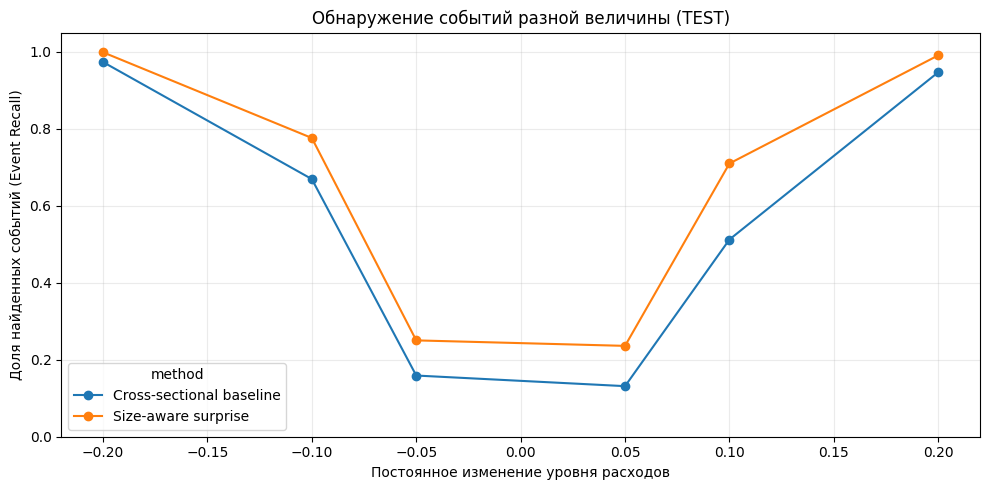

In [11]:
recall_by_delta = (
    TEST_EVENTS.groupby(
        ["method", "delta"],
        as_index=False,
    )
    .agg(
        n_events=("found", "size"),
        event_recall=("found", "mean"),
    )
)

recall_table = recall_by_delta.pivot(
    index="delta",
    columns="method",
    values="event_recall",
)

print("Event Recall по величине синтетического шока:")
display(recall_table.round(4))

ax = recall_table.plot(
    marker="o",
    figsize=(10, 5),
)
ax.set_title("Обнаружение событий разной величины (TEST)")
ax.set_xlabel("Постоянное изменение уровня расходов")
ax.set_ylabel("Доля найденных событий (Event Recall)")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Проверка стабильности выигрыша по муниципалитетам

Для каждого synthetic event в `TEST_EVENTS` известен бинарный признак `found`.
Поэтому bootstrap сравнивает детекторы **на event-level**.

Поскольку одно МО участвует в нескольких TEST seeds,
пересэмплируются целые муниципальные ряды, а не отдельные события.

Доверительный интервал относится к разнице Event Recall
внутри заданного synthetic-протокола.

Это не заменяет проверку на независимом реестре реальных экономических событий.

In [12]:
paired = TEST_EVENTS.pivot_table(
    index=["seed", "series_id"],
    columns="method", values="found", aggfunc="first"
).dropna()

paired["recall_gain"] = (
    paired["Size-aware surprise"].astype(float)
    - paired["Cross-sectional baseline"].astype(float)
)

series_gain = paired.groupby("series_id")["recall_gain"].mean().to_numpy()
rng = np.random.default_rng(2026)
N_BOOT = 3000
boot = np.empty(N_BOOT)
for b in range(N_BOOT):
    idx = rng.integers(0, len(series_gain), size=len(series_gain))
    boot[b] = series_gain[idx].mean()
ci_low, ci_high = np.quantile(boot, [0.025, 0.975])
recall_bootstrap = pd.DataFrame([{
    "paired_mean_recall_gain": float(paired["recall_gain"].mean()),
    "ci_2.5": float(ci_low),
    "ci_97.5": float(ci_high),
    "P(gain>0)": float((boot > 0).mean()),
}])
display(recall_bootstrap.round(4))


,paired_mean_recall_gain,ci_2.5,ci_97.5,P(gain>0)
0,0.0948,0.0792,0.1052,1.0


## 11. Применяем замороженный детектор к реальным месяцам 2024 года

Теперь без каких-либо изменений используем уже выбранные группы, нормировку и пороги на исходных **неизменённых** расходах.

Важно: в реальном мире у нас нет готовой разметки истинных шоков. Поэтому число тревог нельзя автоматически называть числом реальных событий. Следующий ноутбук `05` сгруппирует сигналы в эпизоды и проведёт экономическую интерпретацию.

In [13]:
# За пределами синтетики используются исходные наблюдения.
real = get_alarm_masks(VALUES)
series_threshold = np.array([SIZE_THRESHOLDS[x] for x in size_group])

rows = []
for j, period in enumerate(EVAL_PERIODS):
    origin = period - pd.DateOffset(months=1)
    block = pd.DataFrame({
        "series_id": SERIES_IDS,
        "mo": series_meta["mo"].to_numpy(),
        "period": period,
        "origin": origin,
        "actual_value": VALUES[:, EVAL_POS[j]],
        "prediction": real["prediction"][:, j],
        "log_residual": real["surprise"][:, j],
        "robust_score": real["our_score"][:, j],
        "baseline_cross_section_score": real["baseline_score"][:, j],
        "size_group": size_group,
        "threshold": series_threshold,
        "detected": real["ours"][:, j],
        "baseline_detected": real["baseline"][:, j],
    })
    block["direction"] = np.where(
        block["robust_score"] > 0, "positive", "negative"
    )
    block["surprise_pct"] = 100.0 * (np.exp(block["log_residual"]) - 1.0)
    block["score_ratio"] = block["robust_score"].abs() / block["threshold"]
    rows.append(block)

real_panel = pd.concat(rows, ignore_index=True)
real_signals = real_panel[real_panel["detected"]].copy()
real_signals = real_signals.sort_values(
    ["period", "score_ratio"], ascending=[True, False]
).reset_index(drop=True)

print("Всего проверенных ряд-месяцев:", len(real_panel))
print("Обнаруженных месячных сигналов:", len(real_signals))
print("МО с сигналами:", real_signals["series_id"].nunique())
assert len(real_panel) == 18_144
assert not real_panel.duplicated(["series_id", "period"]).any()
assert (real_signals["score_ratio"] > 1).all()

print("\nПримеры наиболее сильных сигналов:")
display(real_signals.sort_values("score_ratio", ascending=False)[
    ["mo", "period", "direction", "surprise_pct", "score_ratio", "size_group"]
].head(15).round(3))


Всего проверенных ряд-месяцев: 18144
Обнаруженных месячных сигналов: 975
МО с сигналами: 546

Примеры наиболее сильных сигналов:


,mo,period,direction,surprise_pct,score_ratio,size_group
165,внутригородская территория города федерального...,2024-06-01,positive,37.152,4.835,Q4
856,городской округ город Кедровый,2024-12-01,positive,24.300,4.615,Q4
857,городской округ город Коряжма,2024-12-01,positive,21.590,4.147,Q4
267,внутригородская территория города федерального...,2024-07-01,positive,20.611,3.963,Q4
623,городской округ Макаровский,2024-10-01,positive,23.174,3.936,Q4
624,городской округ Южно-Курильский,2024-10-01,positive,15.747,3.913,Q5
736,муниципальный округ Ольский,2024-11-01,positive,14.268,3.406,Q5
625,муниципальный округ Ольский,2024-10-01,positive,12.942,3.289,Q5
386,Котласский муниципальный округ,2024-08-01,negative,-17.360,3.281,Q3
514,городской округ Мамоновский,2024-09-01,positive,28.946,3.046,Q2


### 11.1 Частота тревог по группам и месяцам

Ожидается, что размерно-калиброванный детектор не должен систематически перегружать вниманием только одну размерную группу.

Нельзя добиваться идеально одинаковой частоты: разные МО могут действительно иметь разные риски резких изменений.

Распределение тревог по размерным группам:


,size_group,n_months,n_alarms,alarm_rate_pct
0,Q1,3636,187,5.143
1,Q2,3627,197,5.431
2,Q3,3627,210,5.790
3,Q4,3627,203,5.597
4,Q5,3627,178,4.908


Тревоги по месяцам:


,period,n_alarms,alarm_rate_pct
0,2024-04-01,89,4.415
1,2024-05-01,76,3.770
2,2024-06-01,102,5.060
3,2024-07-01,119,5.903
4,2024-08-01,128,6.349
5,2024-09-01,109,5.407
6,2024-10-01,113,5.605
7,2024-11-01,120,5.952
8,2024-12-01,119,5.903


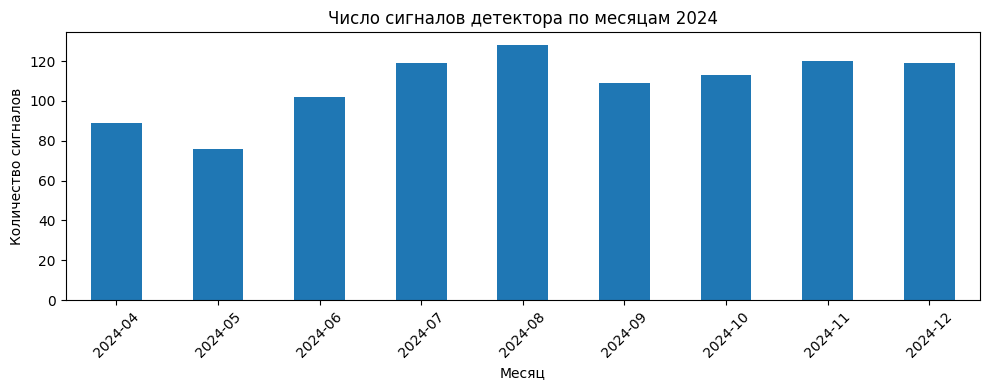

In [14]:
size_alarm_rates = (
    real_panel.groupby("size_group", as_index=False)
    .agg(n_months=("detected", "size"), n_alarms=("detected", "sum"), alarm_rate=("detected", "mean"))
)
size_alarm_rates["alarm_rate_pct"] = 100 * size_alarm_rates["alarm_rate"]
print("Распределение тревог по размерным группам:")
display(size_alarm_rates[["size_group", "n_months", "n_alarms", "alarm_rate_pct"]].round(3))

monthly_alarm_rates = (
    real_panel.groupby("period", as_index=False)
    .agg(n_alarms=("detected", "sum"), alarm_rate=("detected", "mean"))
)
monthly_alarm_rates["alarm_rate_pct"] = monthly_alarm_rates["alarm_rate"] * 100
print("Тревоги по месяцам:")
display(monthly_alarm_rates[["period", "n_alarms", "alarm_rate_pct"]].round(3))

ax = monthly_alarm_rates.plot(
    x="period", y="n_alarms", kind="bar", legend=False, figsize=(10, 4)
)
ax.set_title("Число сигналов детектора по месяцам 2024")
ax.set_xlabel("Месяц")
ax.set_ylabel("Количество сигналов")
plt.xticks(range(len(monthly_alarm_rates)),
           monthly_alarm_rates["period"].dt.strftime("%Y-%m"), rotation=45)
plt.tight_layout()
plt.show()


## 12. Методологическая проверка согласованности

Перед сохранением результатов проверяем:

1. основной benchmark использует `event_recall`, а не mixed-level Precision/F1;
2. все месячные тревоги полностью раскладываются на:
   - фоновые;
   - правильного направления во время активного события;
   - неправильного направления во время активного события;
3. реальный radar воспроизводит операционный результат:
   **975 месячных сигналов в 546 МО**.

Старые значения mixed-level Precision/F1 намеренно больше не используются:
они объединяли event-level TP и month-level alarm rows в одной формуле.

In [15]:
# 1. Полная декомпозиция TEST-тревог.
consistency = TEST_SUMMARY[
    [
        "method",
        "n_alarms",
        "background_alarms",
        "correct_event_alarms",
        "wrong_direction_event_alarms",
        "events_found",
        "other_correct_event_alarms",
    ]
].copy()

consistency["reconstructed_alarms"] = (
    consistency["background_alarms"]
    + consistency["correct_event_alarms"]
    + consistency["wrong_direction_event_alarms"]
)

consistency["alarm_difference"] = (
    consistency["n_alarms"]
    - consistency["reconstructed_alarms"]
)

display(consistency)

assert (consistency["alarm_difference"] == 0).all()

# 2. Воспроизводимость operational radar.
operational_check = pd.DataFrame([
    {
        "metric": "n_real_monthly_signals",
        "current": int(len(real_signals)),
        "expected_reproducibility_check": 975,
    },
    {
        "metric": "n_real_series_with_signals",
        "current": int(real_signals["series_id"].nunique()),
        "expected_reproducibility_check": 546,
    },
])

operational_check["difference"] = (
    operational_check["current"]
    - operational_check["expected_reproducibility_check"]
)

display(operational_check)

assert (operational_check["difference"] == 0).all()

# 3. Финальная TEST-таблица.
final_test_table = TEST_SUMMARY[
    [
        "method",
        "event_recall",
        "mean_delay",
        "share_delay0",
        "false_alarms_100",
        "n_events",
        "events_found",
        "month_precision",
        "month_recall",
        "month_f1",
    ]
].copy()

display(final_test_table.round(4))

print("Методологическая проверка: PASSED")


,method,n_alarms,background_alarms,correct_event_alarms,wrong_direction_event_alarms,events_found,other_correct_event_alarms,reconstructed_alarms,alarm_difference
0,Cross-sectional baseline,5680,2125,3133,422,2834,299,5680,0
1,Size-aware surprise,8406,2273,5906,227,3312,2594,8406,0


,metric,current,expected_reproducibility_check,difference
0,n_real_monthly_signals,975,975,0
1,n_real_series_with_signals,546,546,0


,method,event_recall,mean_delay,share_delay0,false_alarms_100,n_events,events_found,month_precision,month_recall,month_f1
0,Cross-sectional baseline,0.5623,0.0515,0.9633,3.2238,5040,2834,0.5516,0.1263,0.2056
1,Size-aware surprise,0.6571,0.0851,0.9333,3.4483,5040,3312,0.7026,0.2381,0.3557


Методологическая проверка: PASSED


## 12. Дополнительный benchmark: CUSUM и Page–Hinkley

Это **отдельный** эксперимент на тех же 2016 рядах, датах, synthetic events и seeds, что и основной тест. Исходный размерно-адаптивный детектор не изменяется.

Для обоих классических методов применяется двухсторонняя накопительная статистика к нормированному *forecast surprise*. Это последовательные варианты CUSUM и Page–Hinkley; для малой месячной истории статистика инициализируется нулём в начале окна оценки (апрель 2024). CUSUM сравнивает с нулевой базой, а Page–Hinkley использует только накопленное среднее предыдущих месяцев. Параметр допуска `k=0.5` фиксирован до TEST. Пороги выбираются **только на DEV** по сопоставимой фоновой частоте ложных тревог с исходным size-aware detector; среди допустимых вариантов выбирается максимальный DEV event recall. Все 5 TEST seeds остаются независимыми от калибровки.

Сравнение использует ту же signed event-level метрику, задержку, FAR на 100 background row-months и дополнительный signed month-level F1. Результат этих методов не подменяет исходные таблицы и operational signals.

In [16]:
# Классические последовательные детекторы: только дополнительный benchmark.
CLASSICAL_K = 0.5
CLASSICAL_THRESHOLD_GRID = np.array([1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 7, 8, 10, 12, 15], dtype=float)


def classical_signed_statistics(standardized_surprise, k=CLASSICAL_K):
    """Двухсторонние one-sided CUSUM и Page–Hinkley с reset после смены направления.

    Все состояния в месяце t зависят только от входов не позднее t.
    Возвращаем знаковую величину максимального накопленного отклонения.
    """
    x = np.asarray(standardized_surprise, dtype=float)
    n, t = x.shape
    cp = np.zeros((n, t))
    ph = np.zeros((n, t))
    cus_pos = np.zeros(n); cus_neg = np.zeros(n)
    # PH: поэтапная оценка предшествующего среднего, без текущего месяца.
    running_mean = np.zeros(n)
    ph_sum_pos = np.zeros(n); ph_min_pos = np.zeros(n)
    ph_sum_neg = np.zeros(n); ph_min_neg = np.zeros(n)
    for j in range(t):
        z = x[:, j]
        cus_pos = np.maximum(0.0, cus_pos + z - k)
        cus_neg = np.maximum(0.0, cus_neg - z - k)
        cp[:, j] = np.where(cus_pos >= cus_neg, cus_pos, -cus_neg)
        centered = z - running_mean
        ph_sum_pos += centered - k
        ph_sum_neg += -centered - k
        ph_min_pos = np.minimum(ph_min_pos, ph_sum_pos)
        ph_min_neg = np.minimum(ph_min_neg, ph_sum_neg)
        pos = ph_sum_pos - ph_min_pos
        neg = ph_sum_neg - ph_min_neg
        ph[:, j] = np.where(pos >= neg, pos, -neg)
        running_mean += (z - running_mean) / (j + 1)
    return {"CUSUM": cp, "Page-Hinkley": ph}


def classical_seed(seed):
    changed, events, background = inject_persistent_shocks(VALUES, seed)
    # Те же входные значения для сравнения обоих методов.
    _, surprise = forecast_surprise(changed)
    z = size_aware_score(surprise)
    return classical_signed_statistics(z), events, background


# Предварительно кешируем входы по DEV; подбор ведётся без TEST.
_classical_dev = {seed: classical_seed(seed) for seed in DEV_SEEDS}
_target_far = float(DEV_SUMMARY.loc[
    DEV_SUMMARY["method"] == "Size-aware surprise", "false_alarms_100"
].iloc[0])
# Допуск к фоновой нагрузке, заданный до просмотра TEST.
_far_ceiling = _target_far + 0.25
_classical_tuning_rows = []
for method in ["CUSUM", "Page-Hinkley"]:
    for threshold in CLASSICAL_THRESHOLD_GRID:
        metric_rows = []
        for seed in DEV_SEEDS:
            scores, events, background = _classical_dev[seed]
            stat = scores[method]
            row, _ = score_one_scenario(
                np.abs(stat) > threshold, stat, events, background, method
            )
            metric_rows.append(row)
        agg = aggregate_metrics(pd.DataFrame(metric_rows)).iloc[0]
        _classical_tuning_rows.append({
            "method": method,
            "threshold": float(threshold),
            "dev_event_recall": float(agg["event_recall"]),
            "dev_far_100": float(agg["false_alarms_100"]),
        })

CLASSICAL_DEV_GRID = pd.DataFrame(_classical_tuning_rows)
_classical_frozen = {}
for method, part in CLASSICAL_DEV_GRID.groupby("method"):
    feasible = part.loc[part["dev_far_100"] <= _far_ceiling]
    # Даже если нет допустимых значений, берём минимальный DEV FAR;
    # не меняем правило в зависимости от TEST.
    if feasible.empty:
        selected = part.sort_values(
            ["dev_far_100", "dev_event_recall", "threshold"],
            ascending=[True, False, False],
        ).iloc[0]
    else:
        selected = feasible.sort_values(
            ["dev_event_recall", "dev_far_100", "threshold"],
            ascending=[False, True, False],
        ).iloc[0]
    _classical_frozen[method] = float(selected["threshold"])

print("Frozen classical thresholds (DEV only):", _classical_frozen)
print("DEV FAR target / ceiling:", round(_target_far, 3), round(_far_ceiling, 3))

_classical_test_metrics = []
_classical_test_events = []
for seed in TEST_SEEDS:
    scores, events, background = classical_seed(seed)
    for method, threshold in _classical_frozen.items():
        stat = scores[method]
        row, event_df = score_one_scenario(
            np.abs(stat) > threshold, stat, events, background, method
        )
        _classical_test_metrics.append(row)
        _classical_test_events.append(event_df)

CLASSICAL_TEST_METRICS = pd.DataFrame(_classical_test_metrics)
CLASSICAL_TEST_EVENTS = pd.concat(_classical_test_events, ignore_index=True)
CLASSICAL_TEST_SUMMARY = aggregate_metrics(CLASSICAL_TEST_METRICS)
DETECTOR_COMPARISON = pd.concat([
    TEST_SUMMARY,
    CLASSICAL_TEST_SUMMARY,
], ignore_index=True)
assert set(DETECTOR_COMPARISON["method"]) == {
    "Cross-sectional baseline", "Size-aware surprise", "CUSUM", "Page-Hinkley"
}
assert CLASSICAL_TEST_METRICS.groupby("method")["seed"].nunique().eq(len(TEST_SEEDS)).all()
assert CLASSICAL_TEST_EVENTS.groupby("method").size().eq((N_SERIES // 2) * len(TEST_SEEDS)).all()
assert np.isfinite(DETECTOR_COMPARISON["event_recall"]).all()
assert np.isfinite(DETECTOR_COMPARISON["false_alarms_100"]).all()

print("Four-detector independent TEST comparison:")
display(DETECTOR_COMPARISON[[
    "method", "event_recall", "mean_delay", "share_delay0",
    "false_alarms_100", "month_f1", "n_events", "events_found"
]].round(4))
print("Classical benchmark: PASSED")

Frozen classical thresholds (DEV only): {'CUSUM': 5.0, 'Page-Hinkley': 4.5}
DEV FAR target / ceiling: 3.5 3.75
Four-detector independent TEST comparison:


,method,event_recall,mean_delay,share_delay0,false_alarms_100,month_f1,n_events,events_found
0,Cross-sectional baseline,0.5623,0.0515,0.9633,3.2238,0.2056,5040,2834
1,Size-aware surprise,0.6571,0.0851,0.9333,3.4483,0.3557,5040,3312
2,CUSUM,0.5075,0.5301,0.5551,3.2238,0.5535,5040,2558
3,Page-Hinkley,0.4476,0.2983,0.7332,3.4468,0.3296,5040,2256


Classical benchmark: PASSED


## 13. Сохраняем результаты для следующего этапа

В `05_real_shocks_and_attribution_final.ipynb` понадобятся:

- полная панель месячных score;
- отдельная таблица реальных сигналов;
- размерные группы и пороги;
- event-level DEV/TEST benchmark;
- month-level диагностика;
- Event Recall по величине шока;
- bootstrap разницы Event Recall.

Сохраняем итоговые данные в `data/interim`.

In [17]:
OUTPUT_FILES = {
    "panel": INTERIM_DIR / "shock_detector_scored_panel_2024.parquet",
    "signals": INTERIM_DIR / "shock_detector_signals_2024.parquet",
    "size_groups": INTERIM_DIR / "shock_detector_size_groups_2023.parquet",
    "dev_summary": INTERIM_DIR / "shock_detector_dev_summary.csv",
    "test_summary": INTERIM_DIR / "shock_detector_test_summary.csv",
    "test_seeds": INTERIM_DIR / "shock_detector_test_by_seed.csv",
    "recall_delta": INTERIM_DIR / "shock_detector_event_recall_by_delta.csv",
    "recall_bootstrap": INTERIM_DIR / "shock_detector_event_recall_bootstrap.csv",
    "manifest": INTERIM_DIR / "shock_detector_manifest.json",
}

real_panel.to_parquet(OUTPUT_FILES["panel"], index=False)
real_signals.to_parquet(OUTPUT_FILES["signals"], index=False)
size_meta.to_parquet(OUTPUT_FILES["size_groups"], index=False)
DEV_SUMMARY.to_csv(OUTPUT_FILES["dev_summary"], index=False)
TEST_SUMMARY.to_csv(OUTPUT_FILES["test_summary"], index=False)
TEST_METRICS.to_csv(OUTPUT_FILES["test_seeds"], index=False)
recall_by_delta.to_csv(OUTPUT_FILES["recall_delta"], index=False)
recall_bootstrap.to_csv(OUTPUT_FILES["recall_bootstrap"], index=False)

manifest = {
    "project": "Муниципальные расходы: детектор структурных изменений",
    "n_series": int(N_SERIES),
    "evaluation_months": [
        d.strftime("%Y-%m-%d")
        for d in EVAL_PERIODS
    ],
    "forecast": "causal seasonal-growth window=3, h=1",
    "surprise": "log(actual / prediction)",
    "normalization": (
        "cross-sectional median / 1.4826 MAD "
        "within month x 2023 size quintile"
    ),
    "size_thresholds": SIZE_THRESHOLDS,
    "baseline": (
        "difference in panel-median-centered log-YoY, "
        "robust monthly z, threshold=3"
    ),
    "dev_seeds": DEV_SEEDS,
    "test_seeds": TEST_SEEDS,
    "synthetic_shocks": SHOCK_LEVELS.tolist(),
    "synthetic_type": (
        "persistent multiplicative level shift "
        "from onset through Dec-2024"
    ),
    "fraction_injected": 0.5,
    "max_detection_delay_months": MAX_DELAY,

    "primary_evaluation_unit": "synthetic event",
    "event_recall_definition": (
        "events with correct-direction alarm within onset..onset+2 "
        "/ all injected events"
    ),
    "delay_definition": (
        "months from onset to first correct-direction alarm "
        "among detected events"
    ),
    "false_alarm_definition": (
        "alarms in background months before any injected modification "
        "per 100 background series-months"
    ),

    "secondary_month_level_definition": {
        "TP": (
            "correct-direction alarm in an active synthetic-event month"
        ),
        "FP": (
            "alarm in a background month or wrong-direction alarm "
            "in an active event month"
        ),
        "FN": (
            "active synthetic-event month without a "
            "correct-direction alarm"
        ),
    },

    "important_metric_note": (
        "Primary event Precision/F1 are intentionally omitted. "
        "Dividing first detected events by all monthly alarms "
        "mixes event-level and month-level units and penalizes "
        "repeated alarms from one persistent event."
    ),

    "n_real_monthly_signals": int(len(real_signals)),
    "n_real_series_with_signals": int(
        real_signals["series_id"].nunique()
    ),

    "test_metrics": (
        TEST_SUMMARY
        .set_index("method")
        .to_dict(orient="index")
    ),

    "note": (
        "Synthetic validation measures detection of controlled shifts. "
        "It is not ground truth for economic causality."
    ),
}

with open(
    OUTPUT_FILES["manifest"],
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        ensure_ascii=False,
        indent=2,
    )

artifact_status = pd.DataFrame([
    {
        "artifact": path.name,
        "exists": path.exists(),
    }
    for path in OUTPUT_FILES.values()
])

display(artifact_status)
assert artifact_status["exists"].all()

print(
    "Финальные артефакты детектора сохранены в:",
    INTERIM_DIR,
)


# Дополнительный benchmark сохраняется отдельно, старые outputs неизменны.
CLASSICAL_OUTPUT_FILES = {
    "comparison": INTERIM_DIR / "shock_detector_four_method_test_comparison.csv",
    "dev_grid": INTERIM_DIR / "shock_detector_classical_dev_grid.csv",
    "test_seeds": INTERIM_DIR / "shock_detector_classical_test_by_seed.csv",
    "thresholds": INTERIM_DIR / "shock_detector_classical_thresholds.json",
}
DETECTOR_COMPARISON.to_csv(CLASSICAL_OUTPUT_FILES["comparison"], index=False)
CLASSICAL_DEV_GRID.to_csv(CLASSICAL_OUTPUT_FILES["dev_grid"], index=False)
CLASSICAL_TEST_METRICS.to_csv(CLASSICAL_OUTPUT_FILES["test_seeds"], index=False)
with CLASSICAL_OUTPUT_FILES["thresholds"].open("w", encoding="utf-8") as f:
    json.dump({"thresholds": _classical_frozen, "k": CLASSICAL_K,
               "far_ceiling_dev": _far_ceiling,
               "selection": "DEV only"}, f, ensure_ascii=False, indent=2)
print("Four-method benchmark artifacts: SAVED")

,artifact,exists
0,shock_detector_scored_panel_2024.parquet,True
1,shock_detector_signals_2024.parquet,True
2,shock_detector_size_groups_2023.parquet,True
3,shock_detector_dev_summary.csv,True
4,shock_detector_test_summary.csv,True
5,shock_detector_test_by_seed.csv,True
6,shock_detector_event_recall_by_delta.csv,True
7,shock_detector_event_recall_bootstrap.csv,True
8,shock_detector_manifest.json,True


Финальные артефакты детектора сохранены в: <PROJECT_ROOT>/data/interim
Four-method benchmark artifacts: SAVED


### Дополнительное сравнение классических методов

Для расширения сравнительного анализа были реализованы два классических алгоритма обнаружения структурных изменений:

- **CUSUM** — накопление отклонений от ожидаемого поведения;
- **Page–Hinkley** — последовательное обнаружение устойчивого изменения среднего уровня.

Оба метода оценены на том же независимом synthetic TEST, включающем **5 040 структурных событий**.

Пороговые значения выбирались исключительно на DEV и фиксировались до проведения TEST:

- CUSUM: `threshold = 5.0`;
- Page–Hinkley: `threshold = 4.5`.

При калибровке использовался целевой уровень фоновых ложных тревог около 3.5 на 100 ряд-месяцев.

#### Итоговое сравнение четырёх методов

| Метод | Event Recall | Mean Delay | FAR/100 | Month F1 |
|---|---:|---:|---:|---:|
| Cross-sectional baseline | 56.23% | **0.0515** | **3.224** | 20.56% |
| **Size-aware surprise** | **65.71%** | 0.0851 | 3.448 | 35.57% |
| CUSUM | 50.75% | 0.5301 | **3.224** | **55.35%** |
| Page–Hinkley | 44.76% | 0.2983 | 3.447 | 32.96% |

Результаты показывают, что преимущество метода зависит от выбранной метрики.

**Size-aware forecast-surprise detector** продемонстрировал наибольший Event Recall — 65.71%, обнаружив 3 312 из 5 040 событий.

CUSUM, напротив, получил наибольший Month F1 — 55.35%, однако обнаружил меньше событий и имел более высокую среднюю задержку обнаружения.

Cross-sectional baseline обеспечил минимальную среднюю задержку среди обнаруженных событий, но уступил Size-aware по общему охвату событий.

Таким образом, **единственного метода, превосходящего остальные по всем критериям, нет**.

Для задачи Shock Radar выбран Size-aware detector, поскольку основным приоритетом системы является обнаружение как можно большего количества локальных структурных изменений при контролируемой частоте фоновых ложных тревог.

### Ограничения интерпретации

Полученные показатели характеризуют качество алгоритмов на синтетическом benchmark с известными моментами начала событий и контролируемыми величинами изменений.

Они не доказывают способность системы безошибочно устанавливать экономические причины реальных изменений расходов.

Кроме того, Event Recall и Month F1 измеряют различные характеристики обнаружения и не должны интерпретироваться как взаимозаменяемые показатели.

### Финальный вывод

Разработан и протестирован **Size-aware forecast-surprise detector**, использующий отклонение от каузального прогноза и учитывающий масштаб муниципального временного ряда.

На независимом TEST из 5 040 синтетических событий он достиг:

- **Event Recall = 65.71%**;
- **+9.48 процентного пункта** относительно cross-sectional baseline;
- **+478 дополнительно обнаруженных событий**;
- **3.448 фоновых ложных тревоги на 100 ряд-месяцев**;
- bootstrap 95% CI прироста Event Recall: **[+7.92; +10.52] п.п.**

Дополнительное сравнение с CUSUM и Page–Hinkley подтвердило лидерство Size-aware по Event Recall, одновременно выявив преимущество CUSUM по Month F1.

На реальных данных 2024 года Size-aware detector сформировал **975 месячных сигналов в 546 муниципальных образованиях**. Эти сигналы рассматриваются как кандидаты на структурные изменения, требующие дальнейшей интерпретации.

**Выбор Size-aware detector основан на приоритете event-level обнаружения, а не на утверждении его универсального превосходства по всем метрикам.**

Следующий этап — объединение реальных сигналов в shock episodes, категорияльная атрибуция, ранжирование и сопоставление с внешними событиями в ноутбуке `05_real_shocks_and_attribution_final.ipynb`.